# Confusion Matrix Notebook

In this notebook we will create a confusion matrix for the behavioral responses across our glint experiment, for humans and models. 

Essentially we will create 18 x 18 matrix (familiar) and 4 x 4 matrix (novel), Each value in said matrix will correspond to the amount of times say someone gave the response cat for a cat target trial, dog trial, and so one so forth. This way we can see what are the responses participants give for each target object class.

Of importance, you need to go and ge


You will need to exclude participants 

## Adult Confusion Matrix

### Import packages

In [1]:
# Import Necessary Packages 
import os
import pandas as pd
import glob
import numpy as np
import pdb

### Preprocessing the data for all participants

In [61]:
import glob
import pandas as pd

experiment = 'familiar' # set experiment variable to either 'familiar' or 'novel', this will determine which data files we pull and how we structure the summary dataframes


# Define the paths 
base = '/zpool/vladlab/data_drive/glint_master/data/adult_data'
    
core_path = f'{base}/{experiment}_glint' # set core path using experiment variable and base path

# if statement to set the list of excluded participants and objects based on which experiment version we are analyzing (familiar or novel)
if experiment == 'familiar':
    excluded_participants = ['66afcaa60f7d8f58dc21db8e', '66cec5a3fdf1fe2c010e9971']
    objects = ['airplane', 'apple', 'avocado', 'bear', 'binoculars', 'bread', 'butterfly', 'car', 'cat', 'corn', 'cow', 'dog', 'house', 'lawnmower', 'mushroom', 'pineapple', 'snail', 'teapot']
elif experiment == 'novel':
    excluded_participants = ['66a398080da27efcc3e8ecef', '670efd496f9f47e38a4b1d7d', '5aed18cf026e1300018199b3']
    objects = ['krar', 'sarangi', 'sistrum', 'sheng']


# Initialize empty dataframe
participant_summary_df = pd.DataFrame()

sub_summary = pd.DataFrame()

base = '/zpool/vladlab/data_drive/glint_master/data/adult_data'
    
# import the files
files = glob.glob(f'{core_path}/*.csv') 
print(f"You have selected {experiment} glint experiment")


    
for obj in objects:
    for file in files:

        # Take the data for one participant at a time
        data = pd.read_csv(file)

        # Check if the participant is in the excluded list
        if data.loc[0, 'participant'] in excluded_participants:
            continue # skip this participant if they are in the excluded list
        

        '''        
        We apply the exclusion criteria to the data for each participant before we create the summary dataframes.
        Exclusion criteria 1: Remove No responses
        Exclusion criteria 2: Remove RTs less than or equal to 100ms
        Exclusion criteria 3: Remove RTs outside mean ± 2*SD
        
        '''
        # Exclusion criteria 1: Remove No responses
        data_exclusion_1 = data[data['response_label'] != 'no_response']

        # Exclusion criteria 2: Remove RTs less than or equal to 100ms
        data_exclusion_2 = data_exclusion_1[data_exclusion_1['key_resp.rt'] >= 0.1]

        # Exclusion criteria 3: Remove RTs outside mean ± 2*SD
        rt_mean = data_exclusion_2['key_resp.rt'].mean()
        rt_std = data_exclusion_2['key_resp.rt'].std()
        data_exclusion_3 = data_exclusion_2[(data_exclusion_2['key_resp.rt'] >= rt_mean - 2*rt_std) & (data_exclusion_2['key_resp.rt'] <= rt_mean + 2*rt_std)]



        # Filter for the current object class
        if experiment == 'familiar':
            object_trials = data_exclusion_3[data_exclusion_3['object_class'] == obj]
        
        elif experiment == 'novel':
            object_trials = data_exclusion_3[data_exclusion_3['img_class'] == obj]
        
        # Extract only the columns you want
        if experiment == 'familiar':
            subset = object_trials[[
                'participant',
                'img_condition', # condition (natural, scrambled, line_drawing)
                'object_class', # The correct object class of the image they were shown (ex: airplane, car, etc.)
                'object_category', # The animacy category of the image they were shown (animate, inanimate natural, inanimate artificial)
                'response_label', # Response given by subject (ex: car, dog, cat, etc.)
                'response_animacy', # Animacy of the response they gave (animate, inanimate natural, inanimate artificial)
                'key_resp.corr', # Whether the response was correct (1) or incorrect (0)
                'key_resp.keys', # The actual key they pressed for their response
                #'object_class', # The object class of the image they were shown (ex: airplane, car, etc.)
                'prompt_1', # The first prompt they saw for that trial (ex: "Is this a car?")
                'prompt_2', 
                'prompt_3', 
                'prompt_4', 
                'prompt_5', 
                'prompt_6', 
                'prompt_7', 
                'prompt_8', 
                'prompt_9']].copy()
            
        if experiment == 'novel':
            subset = object_trials[[
                'participant',
                'response_label', 
                'key_resp.corr', 
                'key_resp.keys', 
                'condition', 
                'img_class',
                'prompt_1',
                'prompt_2',
                'prompt_3',
                'prompt_4']].copy()
            
        column_map = {
            "reponse_label": "response_by_subject",
            "key_resp.corr": "correct (0=incorrect, 1=correct)",
            "key_resp.keys": "keyboard_response",
            "img_condition": "condition_block",
            "object_category": "correct_animacy",
            "img_class": "correct_object_class",
            "object_class": "correct_object_class"}

        #rename the colimns to standardize across experiment versions
        data = subset.rename(columns=column_map)

        
        # Append to the summary list
        participant_summary_df = pd.concat([participant_summary_df, data], ignore_index=True) #append the subset dataframe for this object class and participant to the overall participant summary dataframe



    # Combine all into one dataframe
    sub_summary = pd.concat([sub_summary, participant_summary_df], ignore_index=True)


You have selected familiar glint experiment


### Familiar Confusion Matrix

In [62]:
import pandas as pd
import numpy as np

fam_objects = ['airplane', 'apple', 'avocado', 'bear', 'binoculars', 'bread', 'butterfly', 'car', 'cat', 'corn', 'cow', 'dog', 'house', 'lawnmower', 'mushroom', 'pineapple', 'snail', 'teapot']
conditions = ['natural', 'scrambled', 'line_drawing']

for condition_name in conditions:
    condition_data = sub_summary[sub_summary['condition_block'] == condition_name]

    counts = pd.crosstab(
        condition_data['correct_object_class'],
        condition_data['response_label']
    )

    counts = counts.reindex(index=fam_objects, columns=fam_objects, fill_value=0)

    row_totals = counts.sum(axis=1)
    response_percent = counts.div(row_totals.replace(0, np.nan), axis=0).fillna(0) * 100

    if condition_name == 'natural':
        confusion_matrix = response_percent.round(1)
    
    elif condition_name == 'scrambled':
        confusion_matrix_scrambled = response_percent.round(1)

    elif condition_name == 'line_drawing':
        confusion_matrix_line_drawing = response_percent.round(1)

    print(condition_name)
    print(response_percent.round(1))
    print("Row sums:")
    print(response_percent.sum(axis=1).round(1))
    print()

natural
response_label        airplane  apple  avocado  bear  binoculars  bread  \
correct_object_class                                                      
airplane                  96.4    0.0      0.5   0.0         0.5    0.0   
apple                      0.0   97.4      0.5   0.0         0.5    0.0   
avocado                    0.0    0.0     96.9   0.0         0.0    0.5   
bear                       0.0    0.0      0.0  96.9         0.0    0.0   
binoculars                 0.5    0.0      0.0   0.0        98.0    0.0   
bread                      0.5    0.0      0.0   0.0         0.0   96.3   
butterfly                  0.0    0.0      0.0   0.5         0.0    0.0   
car                        0.0    0.0      0.0   0.0         0.0    0.0   
cat                        0.0    0.0      0.0   0.0         0.0    0.0   
corn                       0.0    0.0      0.0   0.0         0.0    0.0   
cow                        0.0    0.0      0.0   0.5         1.0    0.0   
dog              

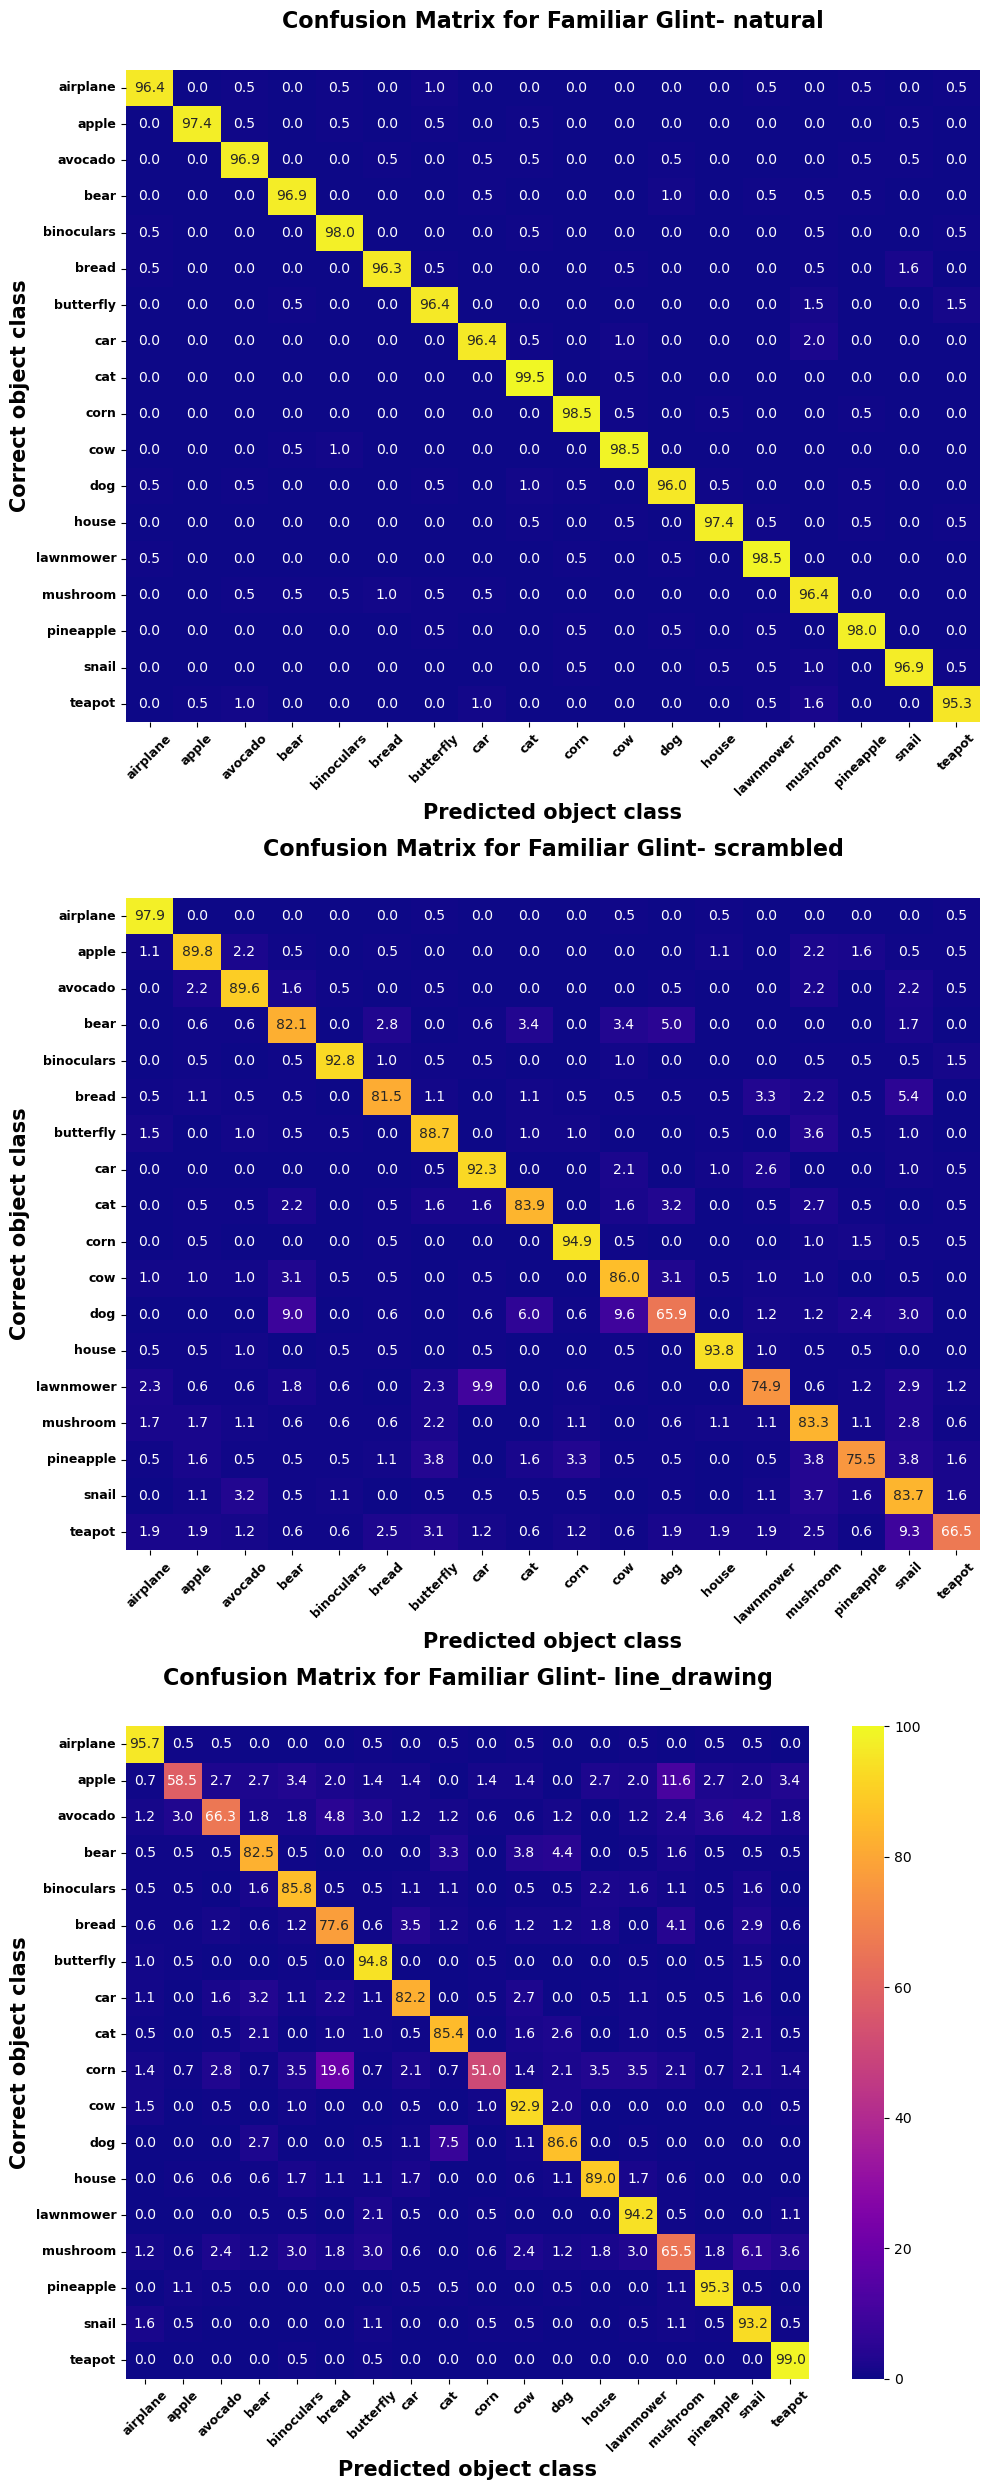

In [71]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

fam_objects = ['airplane', 'apple', 'avocado', 'bear', 'binoculars', 'bread', 'butterfly', 'car', 'cat', 'corn', 'cow', 'dog', 'house', 'lawnmower', 'mushroom', 'pineapple', 'snail', 'teapot']
conditions = ['natural', 'scrambled', 'line_drawing']

fig, axes = plt.subplots(3, 1, figsize=(10, 25), sharey=True)

for ax, condition_name in zip(axes, conditions):
    condition_data = sub_summary[sub_summary['condition_block'] == condition_name]

    counts = pd.crosstab(
        condition_data['correct_object_class'],
        condition_data['response_label']
    )

    counts = counts.reindex(index=fam_objects, columns=fam_objects, fill_value=0)

    response_percent = counts.div(counts.sum(axis=1), axis=0).fillna(0) * 100

    sns.heatmap(
        response_percent,
        ax=ax,
        cmap='plasma', # could also use 'viridis', 'plasma', 'magma', or 'cividis' for better perceptual uniformity
        vmin=0,
        vmax=100,
        annot=True,
        fmt='.1f',
        annot_kws={'fontsize':10},
        cbar=ax is axes[-1]
        
    )

    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9, fontweight='bold')  # Rotate y-axis labels to horizontal
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, fontsize=9, fontweight='bold')  # Rotate x-axis labels for better readability
    ax.set_title(f'Confusion Matrix for Familiar Glint- {condition_name}', fontsize=16, fontweight='bold', pad=30)
    ax.set_xlabel('Predicted object class', fontsize=15, fontweight='bold')
    ax.set_ylabel('Correct object class', fontsize=15, fontweight='bold') 


plt.tight_layout()
plt.show()

### Novel Confusion Matrix

In [48]:
import pandas as pd
import numpy as np


novel_objects = ['krar', 'sarangi', 'sistrum', 'sheng']

conditions = ['natural', 'scrambled', 'line_drawing']

for condition_name in conditions:
    condition_data = sub_summary[sub_summary['condition'] == condition_name]

    counts = pd.crosstab(
        condition_data['correct_object_class'],
        condition_data['response_label']
    )

    counts = counts.reindex(index=novel_objects, columns=novel_objects, fill_value=0)

    row_totals = counts.sum(axis=1)
    response_percent = counts.div(row_totals.replace(0, np.nan), axis=0).fillna(0) * 100

    if condition_name == 'natural':
        confusion_matrix = response_percent.round(1)
    
    elif condition_name == 'scrambled':
        confusion_matrix_scrambled = response_percent.round(1)

    elif condition_name == 'line_drawing':
        confusion_matrix_line_drawing = response_percent.round(1)

    print(condition_name)
    print(response_percent.round(1))
    print("Row sums:")
    print(response_percent.sum(axis=1).round(1))
    print()

natural
response_label        krar  sarangi  sistrum  sheng
correct_object_class                               
krar                  72.0      8.8      8.8   10.3
sarangi               15.9     67.6      4.9   11.6
sistrum               13.4      7.6     70.0    9.0
sheng                  5.5     10.8     11.9   71.8
Row sums:
correct_object_class
krar       100.0
sarangi    100.0
sistrum    100.0
sheng      100.0
dtype: float64

scrambled
response_label        krar  sarangi  sistrum  sheng
correct_object_class                               
krar                  34.4     20.0     24.8   20.8
sarangi               16.1     44.9     17.8   21.2
sistrum               17.7     14.6     50.6   17.1
sheng                 12.2     15.8     12.6   59.5
Row sums:
correct_object_class
krar       100.0
sarangi    100.0
sistrum    100.0
sheng      100.0
dtype: float64

line_drawing
response_label        krar  sarangi  sistrum  sheng
correct_object_class                               
krar       

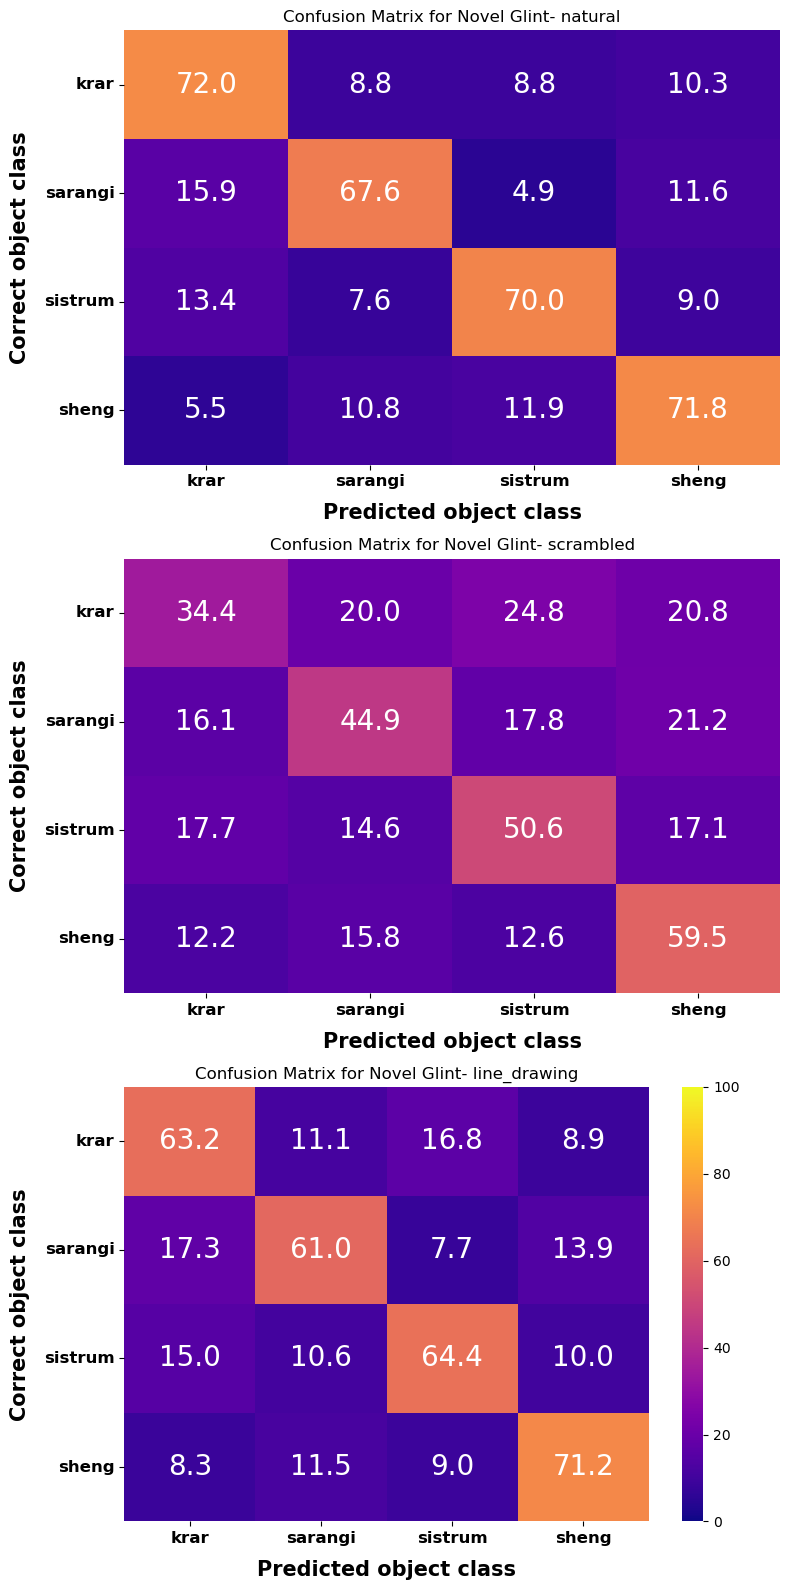

In [59]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

novel_objects = ['krar', 'sarangi', 'sistrum', 'sheng']

conditions = ['natural', 'scrambled', 'line_drawing']

fig, axes = plt.subplots(3, 1, figsize=(8, 16), sharey=True)

for ax, condition_name in zip(axes, conditions):
    condition_data = sub_summary[sub_summary['condition'] == condition_name]

    counts = pd.crosstab(
        condition_data['correct_object_class'],
        condition_data['response_label']
    )

    counts = counts.reindex(index=novel_objects, columns=novel_objects, fill_value=0)

    response_percent = counts.div(counts.sum(axis=1), axis=0).fillna(0) * 100

    sns.heatmap(
        response_percent,
        ax=ax,
        cmap='plasma', # could also use 'viridis', 'plasma', 'magma', or 'cividis' for better perceptual uniformity
        vmin=0,
        vmax=100,
        annot=True,
        fmt='.1f',
        annot_kws={'fontsize':20},
        cbar=ax is axes[-1]        
    )

    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=12, fontweight='bold')  # Rotate y-axis labels to horizontal
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=12, fontweight='bold')  # Rotate x-axis labels for better readability
    ax.set_title(f'Confusion Matrix for Novel Glint- {condition_name}')
    ax.set_xlabel('Predicted object class', fontsize=15, fontweight='bold', labelpad=10)
    ax.set_ylabel('Correct object class', fontsize=15, fontweight='bold', labelpad=10)

plt.tight_layout()
plt.show()

## Child confusion Matrix (under construction!!!)

In [ ]:
import glob
import pandas as pd

experiment = 'familiar' # set experiment variable to either 'familiar' or 'novel', this will determine which data files we pull and how we structure the summary dataframes


# Define the paths 
base = '/zpool/vladlab/data_drive/glint_master/data/child_data'
    
core_path = f'{base}/{experiment}_glint' # set core path using experiment variable and base path

# participants we excluded in our original analysis
excluded_participants = []

# List of object classes in the experiment, which we will loop through to create summary dataframes for each object class
objects = ['airplane', 'apple', 'avocado', 'bear', 'binoculars', 'bread', 'butterfly', 'car', 'cat', 'corn', 'cow', 'dog', 'house', 'lawnmower', 'mushroom', 'pineapple', 'snail', 'teapot']

# Initialize empty dataframe
participant_summary_df = pd.DataFrame()

sub_summary = pd.DataFrame()

base = '/zpool/vladlab/data_drive/glint_master/data/child_data'
    
# import the files
files = glob.glob(f'{core_path}/*.csv') 
print(f"You have selected {experiment} glint experiment")


    
for obj in objects:
    for file in files:

        # Take the data for one participant at a time
        data = pd.read_csv(file)

        # Check if the participant is in the excluded list
        if data.loc[0, 'participant'] in excluded_participants:
            continue # skip this participant if they are in the excluded list
        

        '''        
        We apply the exclusion criteria to the data for each participant before we create the summary dataframes.
        Exclusion criteria 1: Remove No responses
        Exclusion criteria 2: Remove RTs less than or equal to 100ms
        Exclusion criteria 3: Remove RTs outside mean ± 2*SD
        
        '''
        # Exclusion criteria 1: Remove No responses
        data_exclusion_1 = data[data['response_label'] != 'no_response']

        # Exclusion criteria 2: Remove RTs less than or equal to 100ms
        data_exclusion_2 = data_exclusion_1[data_exclusion_1['key_resp.rt'] >= 0.1]

        # Exclusion criteria 3: Remove RTs outside mean ± 2*SD
        rt_mean = data_exclusion_2['key_resp.rt'].mean()
        rt_std = data_exclusion_2['key_resp.rt'].std()
        data_exclusion_3 = data_exclusion_2[(data_exclusion_2['key_resp.rt'] >= rt_mean - 2*rt_std) & (data_exclusion_2['key_resp.rt'] <= rt_mean + 2*rt_std)]



        # Filter for the current object class
        if experiment == 'familiar':
            object_trials = data_exclusion_3[data_exclusion_3['object_class'] == obj]
        
        
        # Extract only the columns you want
        if experiment == 'familiar':
            subset = object_trials[[
                'participant',
                'img_condition', # condition (natural, scrambled, line_drawing)
                'object_class', # The correct object class of the image they were shown (ex: airplane, car, etc.)
                'object_category', # The animacy category of the image they were shown (animate, inanimate natural, inanimate artificial)
                'response_label', # Response given by subject (ex: car, dog, cat, etc.)
                'response_animacy', # Animacy of the response they gave (animate, inanimate natural, inanimate artificial)
                'key_resp.corr', # Whether the response was correct (1) or incorrect (0)
                'key_resp.keys', # The actual key they pressed for their response
                #'object_class', # The object class of the image they were shown (ex: airplane, car, etc.)
                'prompt_1', # The first prompt they saw for that trial (ex: "Is this a car?")
                'prompt_2', 
                'prompt_3', 
                'prompt_4', 
                'prompt_5', 
                'prompt_6', 
                'prompt_7', 
                'prompt_8', 
                'prompt_9']].copy()
            
        if experiment == 'novel':
            subset = object_trials[[
                'participant',
                'response_label', 
                'key_resp.corr', 
                'key_resp.keys', 
                'img_condition', 
                'img_class',
                'prompt_1',
                'prompt_2',
                'prompt_3',
                'prompt_4']].copy()
            
        column_map = {
            "reponse_label": "response_by_subject",
            "key_resp.corr": "correct (0=incorrect, 1=correct)",
            "key_resp.keys": "keyboard_response",
            "img_condition": "condition_block",
            "object_category": "correct_animacy",
            "img_class": "correct_object_class",
            "object_class": "correct_object_class"}

        #rename the colimns to standardize across experiment versions
        data = subset.rename(columns=column_map)

        
        # Append to the summary list
        participant_summary_df = pd.concat([participant_summary_df, data], ignore_index=True) #append the subset dataframe for this object class and participant to the overall participant summary dataframe



    # Combine all into one dataframe
    sub_summary = pd.concat([sub_summary, participant_summary_df], ignore_index=True)


## Model Confusion Matrix

As most of the preprocessing is already done in my modeling script, we can just take the all_models_raw.csv file. Then we will just need to swap some of the variable names to match the names I had in the modelling script.

### Define the path and read in the data

In [32]:
familiar_path = '/zpool/vladlab/data_drive/glint_master/data/model_data/familiar/models_combined/adult_familiar_all_models_raw.csv'

familiar_df = pd.read_csv(familiar_path)
print(familiar_df.head(1))
models = familiar_df['id'].unique()
print(models)


         id classifier experiment_label  number_of_train_imgs condition  \
0  convnext        KNN         familiar                   300   natural   

  test_obj       animacy        obj1  obj2      obj3 obj4       obj5   obj6  \
0     bear  anim_natural  binoculars  bear  mushroom  car  butterfly  bread   

        obj7 obj8      obj9  filtered_acc pred_label adult_or_child  
0  pineapple  cat  airplane           1.0       bear          adult  
['convnext' 'vit']


### Generate the Confusion matrix

In [23]:
import pandas as pd
import numpy as np

fam_objects = ['airplane', 'apple', 'avocado', 'bear', 'binoculars', 'bread', 'butterfly', 'car', 'cat', 'corn', 'cow', 'dog', 'house', 'lawnmower', 'mushroom', 'pineapple', 'snail', 'teapot']
conditions = ['natural', 'shape', 'feature']
models = ['convnext', 'vit']

for condition_name in conditions:
    for model in models:
            
        condition_data = familiar_df[(familiar_df['condition'] == condition_name) & (familiar_df['id'] == model)] # filter for the current condition and model predictions only
        counts = pd.crosstab(
            condition_data['test_obj'],
            condition_data['pred_label']
        )

        counts = counts.reindex(index=fam_objects, columns=fam_objects, fill_value=0)

        row_totals = counts.sum(axis=1)
        response_percent = counts.div(row_totals.replace(0, np.nan), axis=0).fillna(0) * 100

        if condition_name == 'natural':
            confusion_matrix = response_percent.round(1)
        
        elif condition_name == 'shape':
            confusion_matrix_scrambled = response_percent.round(1)

        elif condition_name == 'feature':
            confusion_matrix_line_drawing = response_percent.round(1)
        print(model)
        print(condition_name)
        print(response_percent.round(1))
        print("Row sums:")
        print(response_percent.sum(axis=1).round(1))
        print()

convnext
natural
pred_label  airplane  apple  avocado   bear  binoculars  bread  butterfly  \
test_obj                                                                    
airplane       100.0    0.0      0.0    0.0         0.0    0.0        0.0   
apple            0.0  100.0      0.0    0.0         0.0    0.0        0.0   
avocado          0.0    0.0    100.0    0.0         0.0    0.0        0.0   
bear             0.0    0.0      0.0  100.0         0.0    0.0        0.0   
binoculars       0.0    0.0      0.0    0.0       100.0    0.0        0.0   
bread            0.0    0.0      0.0    0.0         0.0  100.0        0.0   
butterfly        0.0    0.0      0.0    0.0         0.0    0.0      100.0   
car              0.0    0.0      0.0    0.0         0.0    0.0        0.0   
cat              0.0    0.0      0.0    0.0         0.0    0.0        0.0   
corn             0.0    0.0      0.0    0.0         0.0    0.0        0.0   
cow              0.0    0.0      0.0    0.0         0.0    

### Let's plot it as a figure

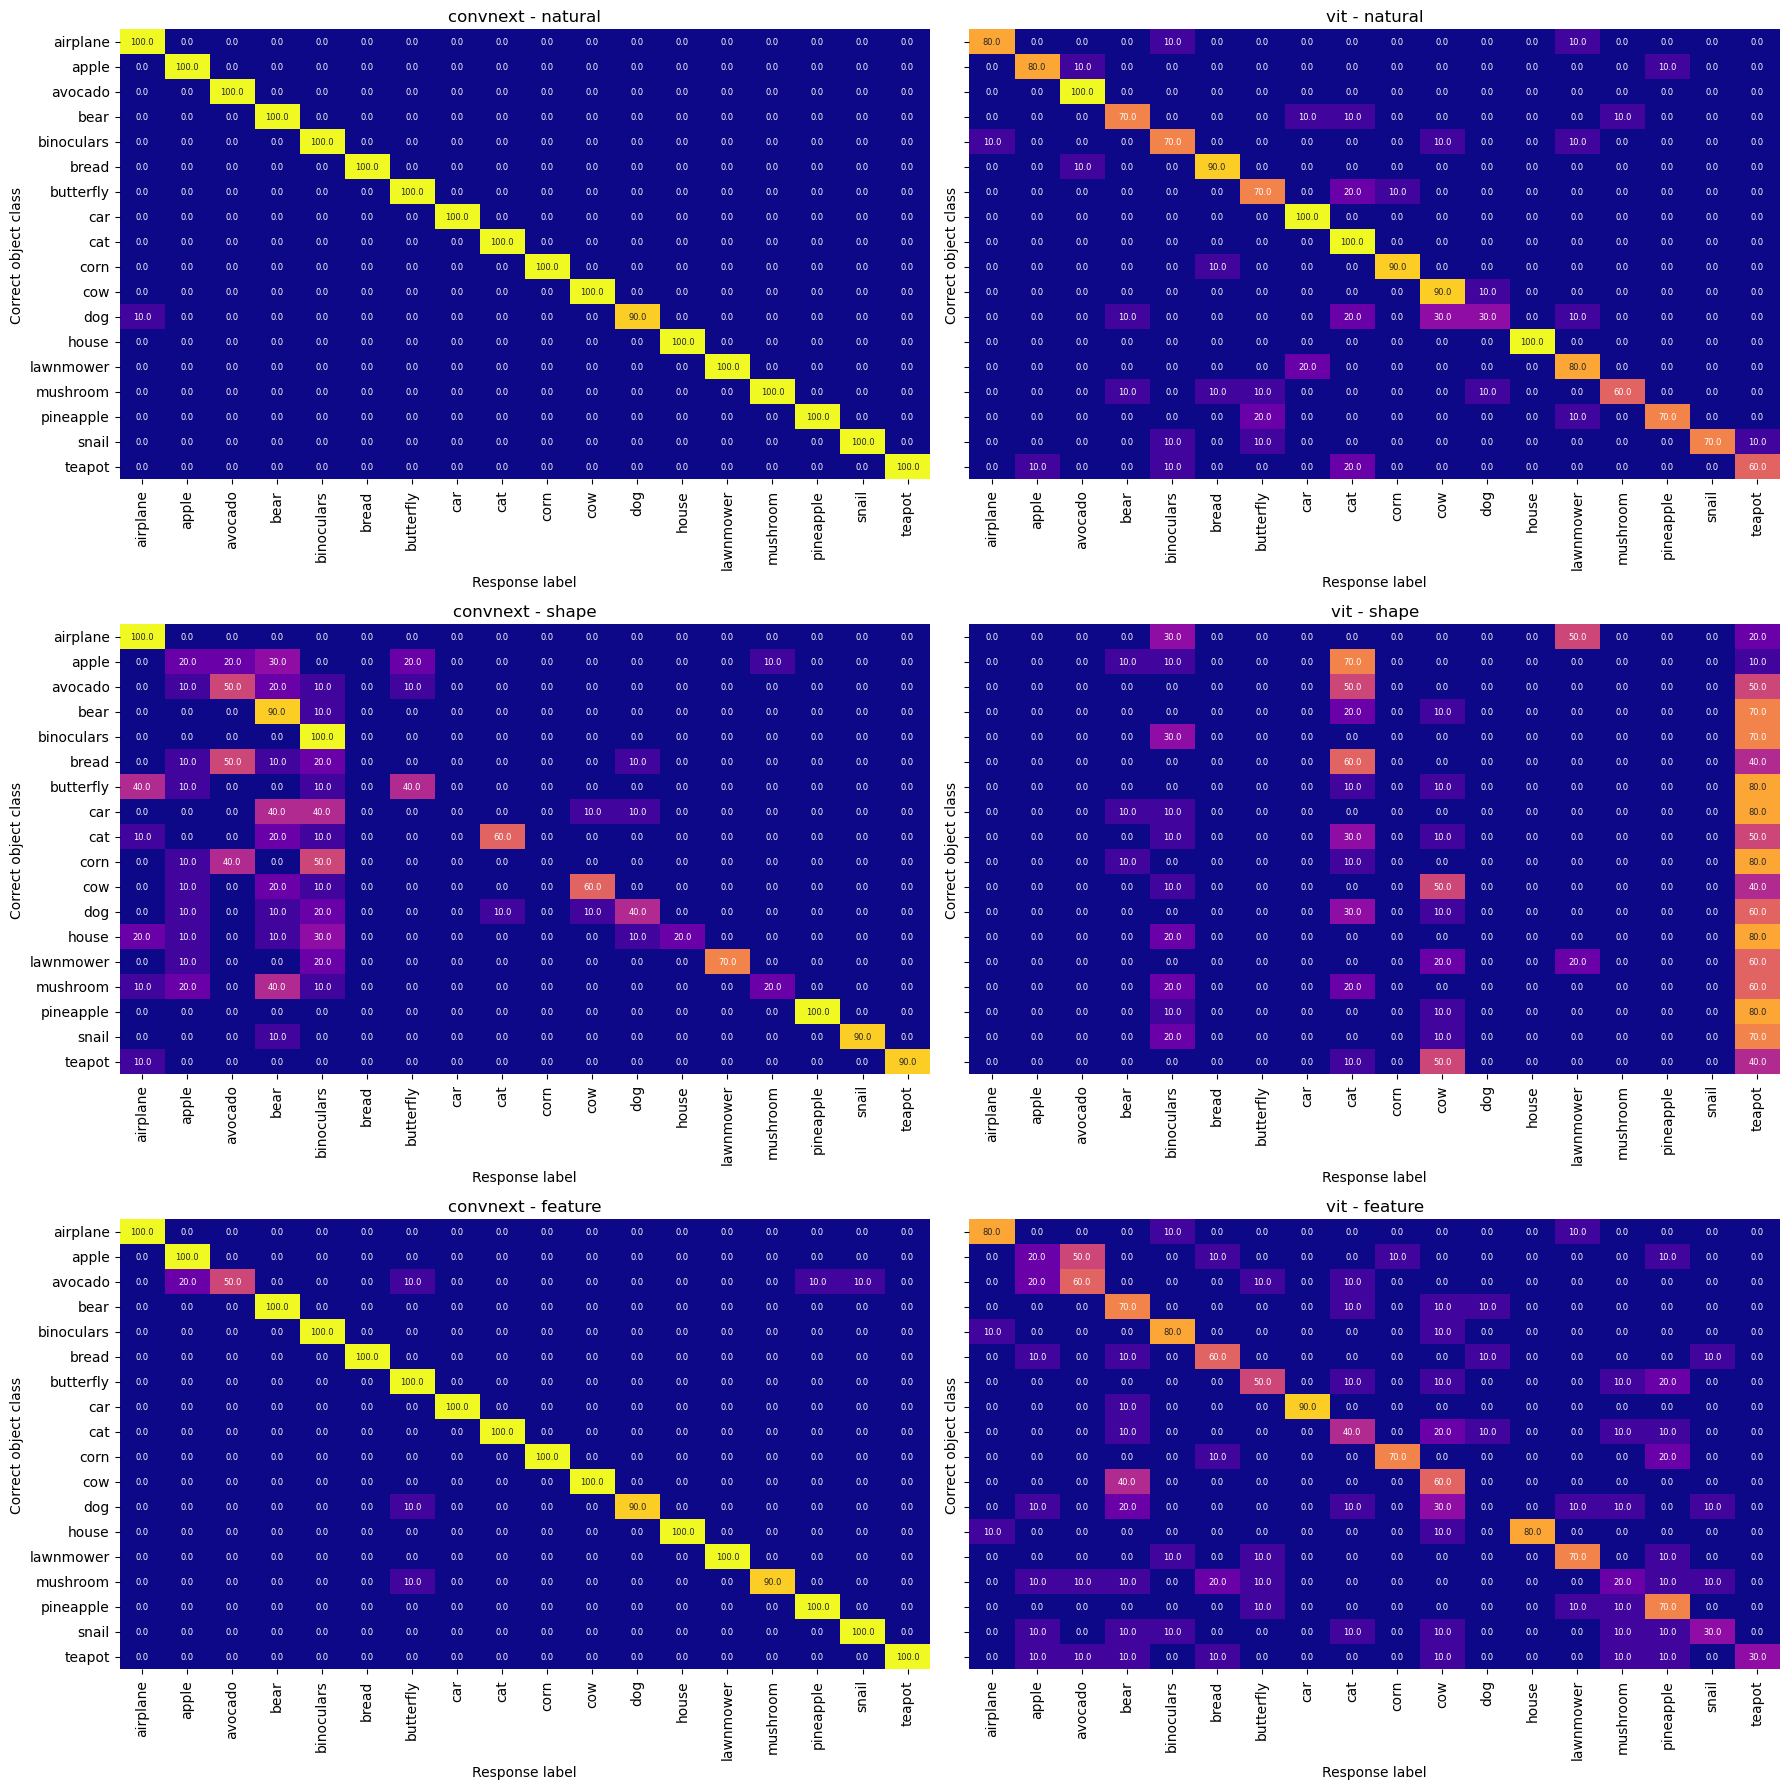

In [43]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

fam_objects = ['airplane', 'apple', 'avocado', 'bear', 'binoculars', 'bread', 'butterfly', 'car', 'cat', 'corn', 'cow', 'dog', 'house', 'lawnmower', 'mushroom', 'pineapple', 'snail', 'teapot']
conditions = ['natural', 'shape', 'feature']
models = ['convnext', 'vit']


fig, axes = plt.subplots(len(conditions), len(models), figsize=(18, 18), sharey=True)

for i, condition in enumerate(conditions):
    for j, model in enumerate(models):
        ax = axes[i, j]
        condition_data = familiar_df[(familiar_df['condition'] == condition) & (familiar_df['id'] == model)] # filter for the current condition and model predictions only
        counts = pd.crosstab(
            condition_data['test_obj'],
            condition_data['pred_label']
        )

        counts = counts.reindex(index=fam_objects, columns=fam_objects, fill_value=0)

        response_percent = counts.div(counts.sum(axis=1), axis=0).fillna(0) * 100

        sns.heatmap(
            response_percent,
            ax=ax,
            cmap='plasma', # could also use 'viridis', 'plasma', 'magma', or 'cividis' for better perceptual uniformity
            vmin=0,
            vmax=100,
            annot=True,
            fmt='.1f',
            annot_kws={'fontsize':6},
            cbar=ax is axes[-1]
            
        )

        ax.set_title(f'{model} - {condition}')
        ax.set_xlabel('Response label')
        ax.set_ylabel('Correct object class')

plt.tight_layout()
plt.show()